In [15]:
!pip install bangla-stemmer


  Using cached bangla_stemmer-1.0-py3-none-any.whl.metadata (2.4 kB)
Using cached bangla_stemmer-1.0-py3-none-any.whl (9.1 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import numpy as np
import pandas as pd
newdata = pd.read_csv("../data/final_bn_data.csv")
newdata.head()

,category,headline,content,label
0,National,৮ দিনে ১৮ বিল পাস!,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,Sports,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোড,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,National,মাদ্রাসায় জোড়া খুন: পরিচালক তিন দিনের রিমান্ডে,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,Sports,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশ,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,National,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধার,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [53]:
newdata= newdata.drop(['headline', 'category'], axis=1)
newdata.to_csv('newDataset.csv', index=False)


In [54]:
# Install required package
!pip install bangla-stemmer  # CHANGED: kept same

import pandas as pd
import re
import string
from bangla_stemmer.stemmer import stemmer

# Bangla stopwords list (keep your full list)
bangla_stopwords = set([  # CHANGED: converted to set for faster lookup
    'অবশ্য','অনেক','অনেকে','অনেকেই','অন্তত','অন্য','আজ','আছে','আপনার','আপনি',
'আবার','আমরা','আমাকে','আমাদের','আমার','আমি','আরও','আর','আগে','আগেই','আই',
'অতএব','আগামী','অবধি','অনুযায়ী','আদ্যভাগে','এই','একই','একে','একটি','এখন',
'এখনও','এখানে','এখানেই','এটি','এটা','এটাই','এতটাই','এবং','একবার','এবার',
'এদের','এঁদের','এমন','এমনকী','এল','এর','এরা','এঁরা','এস','এতে','এসে','এ',
'ঐ','ই','ইহা','ইত্যাদি','উনি','উপর','উপরে','উচিত','ও','ওই','ওর','ওরা','ওঁর',
'ওঁরা','ওকে','ওদের','ওঁদের','ওখানে','কত','কবে','করতে','কয়েক','কয়েকটি','করবে',
'করলেন','করার','কারও','করা','করি','করিয়ে','করাই','করলে','করিতে','করিয়া','করেছিলেন',
'করছে','করছেন','করেছেন','করেছে','করেন','করবেন','করায়','করে','করেই','কাছ','কাছে',
'কাজে','কারণ','কিছু','কিছুই','কিন্তু','কিংবা','কি','কী','কেউ','কেউই','কাউকে','কেন',
'কে','কোনও','কোনো','কোন','কখনও','ক্ষেত্রে','খুব','গুলি','গিয়ে','গিয়েছে','গেছে',
'গেল','গেলে','গোটা','চলে','ছাড়া','ছাড়াও','ছিলেন','ছিল','জন্য','জানা','ঠিক','তিনি',
'তিনঐ','তিনিও','তখন','তবে','তবু','তাঁদের','তাঁরা','তাঁর','তাঁকে','তাই','তেমন','তাকে',
'তাহা','তাহাতে','তাহার','তাদের','তারপর','তারা','তার','তাহলে','তা','তাও','তাতে','তো',
'তত','তুমি','তোমার','তথা','থাকে','থাকা','থাকায়','থেকে','থেকেও','থাকবে','থাকেন',
'থাকবেন','থেকেই','দিকে','দিতে','দিয়ে','দিয়েছে','দিয়েছেন','দিলেন','দু','দুটি','দুটো',
'দেয়','দেওয়া','দেওয়ার','দেখা','দেখে','দেখতে','দ্বারা','ধরে','ধরা','নয়','নানা','না',
'নাকি','নাগাদ','নিতে','নিজে','নিজেই','নিজের','নিজেদের','নিয়ে','নেওয়া','নেওয়ার','নেই',
'নাই','পক্ষে','পর্যন্ত','পাওয়া','পারেন','পারি','পারে','পরে','পরেই','পরেও','পর','পেয়ে',
'প্রতি','প্রভৃতি','প্রায়','ফের','ফলে','ব্যবহার','বলতে','বললেন','বলেছেন','বলল','বলা',
'বলেন','বলে','বহু','বসে','বার','বা','বিনা','বরং','বদলে','বাদে','বিশেষ','বিভিন্ন',
'বিষয়টি','ব্যাপারে','ভাবে','ভাবেই','মধ্যে','মধ্যেই','মধ্যেও','মধ্যভাগে','মাধ্যমে','মাত্র',
'মতো','মতোই','মোটেই','যখন','যদি','যদিও','যাবে','যায়','যাকে','যাওয়া','যাওয়ার','যত',
'যতটা','যা','যার','যারা','যাঁর','যাঁরা','যাদের','যান','যাচ্ছে','যেতে','যাতে','যেন','যেমন',
'যেখানে','যিনি','যে','রেখে','রাখা','রয়েছে','রকম','শুধু','সঙ্গে','সঙ্গেও','সমস্ত','সব',
'সবার','সহ','সুতরাং','সহিত','সেই','সেটা','সেটি','সেটাই','সেটাও','সম্প্রতি','সেখান',
'সেখানে','সে','স্পষ্ট','স্বয়ং','হইতে','হইবে','হৈলে','হইয়া','হচ্ছে','হত','হতে','হতেই',
'হবে','হবেন','হয়েছিল','হয়েছে','হয়েছেন','হয়ে','হয়নি','হয়','হয়েই','হয়তো','হল','হলে',
'হলেই','হলেও','হলো','হিসাবে','হওয়া','হওয়ার','হওয়ায়','হন','হোক','জন','জনকে','জনের',
'জানতে','জানায়','জানিয়ে','জানানো','জানিয়েছে','জন্য','জন্যওজে','জে','বেশ','দেন','তুলে',
'ছিলেন','চান','চায়','চেয়ে','মোট','যথেষ্ট','টি','অনুযায়ী','উত্তর','কমনে','প্রথম','প্রযন্ত',
'প্রাথমিক','মনে','নতুন','পি','পেয়্র্','বক্তব্য','ধামার','সি','সাধারণ','সামনে','হাজার'
])

# Simple stemmer for common suffixes (same as your function)
def simple_bangla_stem(word):
    suffixes = ["গুলো", "দের", "মতো", "গুলোই", "টিতে", "টার", "রা", "টি", "টা", "তে", "র", "এর", "ই", "ও"]
    for suf in sorted(suffixes, key=len, reverse=True):
        if word.endswith(suf) and len(word) > len(suf) + 1:
            return word[:-len(suf)]
    return word

# Normalization dictionary (same, just cleaned formatting)
bangla_normalization_dict = {
    "মুরগি": "মুরগি",
    "মুরগী": "মুরগি",
    "মুরগীটা": "মুরগি",
    "মুরগিটা": "মুরগি",
    "মুরগিগুলো": "মুরগি",
    "শিয়াল": "শিয়াল",
    "শেয়াল": "শিয়াল",
    "শিয়াল": "শিয়াল",
    "মানুষ": "মানুষ",
    "মাঞ্জুষ": "মানুষ",
    "মানুষটা": "মানুষ",
    "ভিডি": "ভিডিও",
    "ফরান্স": "ফ্রান্স",
    "খাচ্ছে": "খাওয়া",
    "খাচ্ছেন": "খাওয়া",
    "খায়": "খাওয়া",
    "খেতে": "খাওয়া",
    "খেয়েছে": "খাওয়া",
    "দেয়": "দেওয়া",
    "দিচ্ছে": "দেওয়া",
    "দিয়েছে": "দেওয়া",
    "কিংবা": "কিন্তু",
    "একটি": "এক",
    "দুইটি": "দুই",
    # add more as needed
}

# Suppress print outputs from stemmer
import sys, io
def suppress_stdout(func, *args, **kwargs):
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        result = func(*args, **kwargs)
    finally:
        sys.stdout = old_stdout
    return result

# Main preprocessing function
def preprocessNew_bangla_text(text):
    text = str(text)

    # Remove HTML, URLs, emails, hashtags, Latin letters, and numbers
    text = re.sub(r"<.*?>|http\S+|www\S+|\S*@\S*|\#\S*", " ", text)  # CHANGED: combined into one regex
    text = re.sub(r"[a-zA-Z০-৯0-9]+", " ", text)  # CHANGED: removed unnecessary parts

    # Remove punctuation
    punct_pattern = f"[{string.punctuation}।॥‘’“”—৳]"  # CHANGED: unified punctuation
    text = re.sub(punct_pattern, " ", text)

    # Normalize certain characters
    text = re.sub("[য়য়]", "য়", text)
    text = re.sub("[ঋৃ]", "ঋ", text)
    text = re.sub("[ঁ্]", "", text)
    text = re.sub(r"\s+", " ", text).strip()  # CHANGED: condensed whitespace cleanup

    # Remove consecutive repeated words
    words = text.split()
    words = [words[i] for i in range(len(words)) if i == 0 or words[i] != words[i-1]]  # CHANGED: list comprehension

    # Normalize words using dictionary
    words = [bangla_normalization_dict.get(w, w) for w in words]  # CHANGED: more pythonic

    # Remove stopwords
    words = [w for w in words if w not in bangla_stopwords]  # CHANGED: set lookup faster

    # Apply simple stemming
    words = [simple_bangla_stem(w) for w in words]

    return " ".join(words)

# Load dataset
new_data = pd.read_csv("newDataset.csv")

# Apply preprocessing
new_data['content'] = new_data['content'].apply(preprocessNew_bangla_text)  # CHANGED: applied vectorized apply

# Preview results
for original, processed in zip(new_data['content'][:5], new_data['content'][:5]):  # CHANGED: preview 5 rows instead of 2
    print("Original:", original)
    print("Processed:", processed)
    print("-" * 50)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Original: দশম জাতীয় সংস মেয়াদ শেষ য়াচছে কারয়ত মাত এক অধিবেশন বরতমান সরকারে অকটোবরে মাঝামাঝি সংকষিপত এক অধিবেশন ডেকে ‍ইিত টানা সংসেদ এরপ ডিসেমবরে শেষ সপতাহে একাদশ সংসদ নিরবাচনে য়া সংখয়াগরিষঠতা পাবেন তারা সরকা গঠন জানুয়ারি বস সরকারে পরথম অধিবেশন বরতমান সরকারে পাচ বছ পূরণ হচছে বছরে জানুয়ারি সংবিধান অনুয়ায়ী বিদয়মান সংসদ ভেঙে আগে দিনে মধয়ে পরবরতী সংসদ নিরবাচন কথা হিসেবে অকটোব নিরবাচনে কাউন ডাউন শুরু সরকারে বিভিনন মহলে আলোচনা পরিপরেকষি ধারণা হচছে অকটোবরে মধয় নিরবাচনকালীন সরকা গঠন সরকা রুটিন ওয়ারক দেশে উদবুদধ পরিসথিতি সঋষ রাষটরপতি চাইলে য়েকোনো সময় অধিবেশন আহবান এদিকে দশম জাতীয় সংস তম অধিবেশন রেকরডে খাতায় লেখা কেননা অধিবেশনে মাত আট কারয়দিবসে মধয়ে ইতোমধয়ে বিল পাস শেষ দিনে চার পাস য়াচছে হিসেবে অননয় উচচতায় অধিবেশন এতো অলপ সময়ে সংখয়ক বিল পাসে নজি গত সেপটেমব শুরু তম অধিবেশন য়া সেপটেমব শেষ য়াচছে শুক শনিবা বাদ টানা কারয়দিবস অধিবেশন পরথম দিন বরতমান সংস সদসয়ে মঋতয়ু শোক পরসতাব গঋহীত অনয়ানয় সকল কারয়সূচি সথগিত তাছাড়া সেপটেমব বিদয়ুৎ বিপরয়য়ে কারণে এক ঘণ অধিবেশন চালানো সথগিত য়ায় কারণে দিন চললে মূলত কারয়দিবসে

In [56]:
class_counts = newdata['label'].value_counts()
print(class_counts)

label
1.0    10000
0.0     4537
Name: count, dtype: int64


In [60]:
new_data = pd.read_csv("newDataset.csv")
newdata.head()

,content,label
0,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [ ]:
#logistic regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np

# Load dataset
nd = pd.read_csv('newDataset.csv')  
X = nd['content']  
y = nd['label']      


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(1,3),
    sublinear_tf=True,
    lowercase=True
)
X_train_vect = tfidf.fit_transform(X_train)
X_test_vect = tfidf.transform(X_test)

# Logistic Regression with class balancing
clf = LogisticRegression(class_weight='balanced', max_iter=2000, solver='saga', random_state=42)

# Hyperparameter tuning for C (regularization strength)
param_grid = {'C': [0.1, 0.5, 1, 2, 5]}
grid = GridSearchCV(clf, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
grid.fit(X_train_vect, y_train)

best_clf = grid.best_estimator_
print(f"Best C: {grid.best_params_['C']}")

# Predict probabilities 
y_prob = best_clf.predict_proba(X_test_vect)[:,1]
threshold = 0.48  
y_pred = (y_prob >= threshold).astype(int)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Best C: 5

Test Accuracy: 0.7510

Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.64      0.62       908
         1.0       0.83      0.80      0.82      2000

    accuracy                           0.75      2908
   macro avg       0.71      0.72      0.72      2908
weighted avg       0.76      0.75      0.75      2908

Confusion Matrix:
[[ 582  326]
 [ 398 1602]]


In [65]:
 !pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#SVM
import bangla_stemmer
from sklearn.calibration import LinearSVC
from imblearn.over_sampling import SMOTE

newdata = pd.read_csv("newDataset.csv")



X = newdata['content']
y = newdata['label']


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  TF-IDF Vectorization
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


#  Handle Imbalanced Classes using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_tfidf, y_train)

print("Original train label distribution:", Counter(y_train))
print("Resampled train label distribution:", Counter(y_resampled))


#  Train LinearSVC with GridSearch

svm = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

param_grid = {'C': [0.01, 0.1, 1, 5, 10]}

grid = GridSearchCV(svm, param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_resampled, y_resampled)

best_svm = grid.best_estimator_
print("Best C:", grid.best_params_['C'])
print("Best cross-validated F1-weighted score:", grid.best_score_)


#  Predictions and Evaluation

y_pred = best_svm.predict(X_test_tfidf)

print("Optimized SVM Classification Report")
print(classification_report(y_test, y_pred))


Original train label distribution: Counter({1.0: 8000, 0.0: 3629})
Resampled train label distribution: Counter({1.0: 8000, 0.0: 8000})
Best C: 5
Best cross-validated F1-weighted score: 0.866172864045668
Optimized SVM Classification Report
              precision    recall  f1-score   support

         0.0       0.60      0.59      0.59       908
         1.0       0.82      0.82      0.82      2000

    accuracy                           0.75      2908
   macro avg       0.71      0.70      0.71      2908
weighted avg       0.75      0.75      0.75      2908



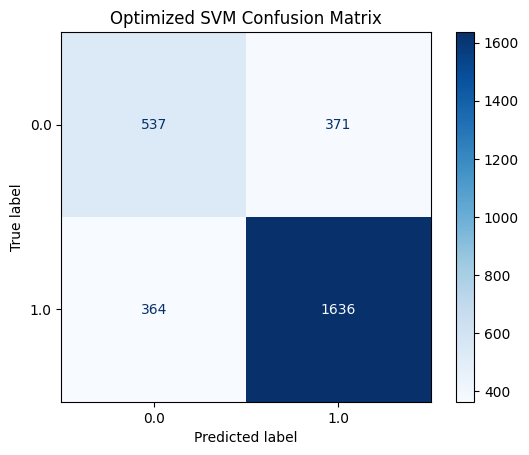

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred, labels=best_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Optimized SVM Confusion Matrix")
plt.show()


In [72]:
!pip install transformers datasets torch


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch


MODEL_NAME = "sagorsarker/bangla-bert-base"  # Bangla BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [77]:
from torch.utils.data import Dataset

class BanglaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [87]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torchaudio


In [89]:
!pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.9.1
Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1


You can safely remove it manually.


In [90]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [92]:
import sys
print(sys.executable)


c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Scripts\python.exe


In [100]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm

new_data = pd.read_csv("newDataset.csv")

X_train, X_test, y_train, y_test = train_test_split(
    new_data['content'],
    new_data['label'],
    test_size=0.2,
    random_state=42,
    stratify=new_data['label']
)

#  Bangla BERT
MODEL_NAME = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

class BanglaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


train_dataset = BanglaNewsDataset(X_train, y_train, tokenizer)
test_dataset = BanglaNewsDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


optimizer = AdamW(model.parameters(), lr=2e-5)


epochs = 1

for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        loop.set_description(f'Epoch {epoch+1}')
        loop.set_postfix(loss=loss.item())


model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("Classification Report on Test Set:")
print(classification_report(y_true, y_pred))

#  Saving the fine-tuned model
model.save_pretrained("Bert_On_newData")

import gc

# free unused memory to release file locks
torch.cuda.empty_cache()
gc.collect()

SAVE_DIR = "bangla_bert_fake_news_v4"  


model.save_pretrained(SAVE_DIR, safe_serialization=False)
tokenizer.save_pretrained(SAVE_DIR)

print(f" Model and tokenizer saved successfully to '{SAVE_DIR}'")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 727/727 [47:55<00:00,  3.96s/it, loss=0.492]


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       908
           1       0.76      0.86      0.81      2000

    accuracy                           0.72      2908
   macro avg       0.67      0.64      0.64      2908
weighted avg       0.71      0.72      0.71      2908



ModuleNotFoundError: No module named 'torch.utils.serialization'

In [ ]:
#random forest
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("newDataset.csv")
texts = data['content']       
labels = data['label']     

# Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

X = vectorizer.transform(texts)
y = labels.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest with balanced class weights
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.734869325997249
Confusion Matrix:
 [[ 335  611]
 [ 160 1802]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.35      0.46       946
         1.0       0.75      0.92      0.82      1962

    accuracy                           0.73      2908
   macro avg       0.71      0.64      0.64      2908
weighted avg       0.72      0.73      0.71      2908



In [83]:

!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 1.9 MB/s eta 0:00:38
    --------------------------------------- 1.0/72.0 MB 2.2 MB/s eta 0:00:33
    --------------------------------------- 1.6/72.0 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.1/72.0 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 2.4/72.0 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.9/72.0 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 3.4/72.0 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 4.2/72.0 MB 2.4 MB/s eta 0:00:28
   --- ------------------------------------ 5.8/72.0 MB 3.0 MB/s eta 0:00:23
   --- ------------------------------------ 7.1/72.0 MB 3.3 MB/s eta 0:00:20
   ---- ----------------------------------- 8.1/72.0 MB 3.6 MB/s eta 0:00:18
   ----- ----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Xgboost
import xgboost as xgb
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# 1Load processed dataset
data = pd.read_csv("newDataset.csv")  
texts = data['content']    
labels = data['label']  

#  Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Transform texts to TF-IDF features
X = vectorizer.transform(texts)
y = labels.values

#  Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=10,
    scale_pos_weight=5,  # balances minority class
    random_state=42
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7444979367262724
Confusion Matrix:
 [[ 365  581]
 [ 162 1800]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.39      0.50       946
         1.0       0.76      0.92      0.83      1962

    accuracy                           0.74      2908
   macro avg       0.72      0.65      0.66      2908
weighted avg       0.74      0.74      0.72      2908



In [ ]:
#Xgboost fine-tuned
import xgboost as xgb
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


data = pd.read_csv("newDataset.csv")  
texts = data['content']    
labels = data['label']     

#  Load TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Transform texts to TF-IDF features
X = vectorizer.transform(texts)
y = labels.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Def XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=500,      
    max_depth=8,           
    learning_rate=0.05,    
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(), 
    subsample=0.8,       
    colsample_bytree=0.8,  
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)


# train 
xgb_model.fit(X_train, y_train)

#  Predict and evaluate
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

# 8. Save model 
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)


c:\Users\User\Desktop\Bangla_Fake_News_detection\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:14:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7551581843191196
Confusion Matrix:
 [[ 568  340]
 [ 372 1628]]
Classification Report:
               precision    recall  f1-score   support

         0.0     0.6043    0.6256    0.6147       908
         1.0     0.8272    0.8140    0.8206      2000

    accuracy                         0.7552      2908
   macro avg     0.7157    0.7198    0.7176      2908
weighted avg     0.7576    0.7552    0.7563      2908

